<a href="https://colab.research.google.com/github/allythe/HorizonDetection/blob/main/DatasetFromCVAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import cv2
import xml.etree.ElementTree as ET
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import subprocess
import shutil

In [ ]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [ ]:
!ls /content/drive/MyDrive/MIUN/QRD/implementation/

 Algorithms.ipynb
 Analysis.ipynb
 DatasetFromCVAT.ipynb
'horizon_coordinates_all (1).gsheet'
 horizon_coordinates_all.csv
 horizon_coordinates_all.gsheet
 horizon_detection_h_cov_lum_results.csv
 horizon_detection_h_hc_results.csv
 horizon_detection_h_lsc_results.csv
 images
 results
 resultshorizon_dexined_analysis_results.csv
 resultshorizon_h_cov_lum_analysis_results.csv
 resultshorizon_h_med_analysis_results.csv
 resultshorizon_segment_analysis_results.csv
 videos


# Find video and annotation file

In [ ]:
name = "first"
name_data = "boat_ice_1"


In [ ]:
VIDEO_DIR = "/content/drive/MyDrive/MIUN/QRD/implementation/videos" # folder next to your notebook

# Find your XML and video files
ann_filename = None
video_filename = None

for f in os.listdir(VIDEO_DIR):
    if f.lower().endswith(".xml") and name in f.lower():
        ann_filename = os.path.join(VIDEO_DIR, f)
    elif f.lower().endswith((".webm", ".mp4", ".avi", ".mov")) and name in f.lower():
        video_filename = os.path.join(VIDEO_DIR, f)

if not ann_filename or not video_filename:
    raise FileNotFoundError("Could not find .xml and video file in the 'videos' folder!")

print(f"Found annotation: {ann_filename}")
print(f"Found video: {video_filename}")


Found annotation: /content/drive/MyDrive/MIUN/QRD/implementation/videos/first_video.xml
Found video: /content/drive/MyDrive/MIUN/QRD/implementation/videos/first_video.webm


# Parse annotations, keep only those which have horizon

In [ ]:
def parse_cvat_xml(path, target_label="horizon"):
    """Return dict: {frame_id: [ [x1,y1], [x2,y2], ... ]}"""
    tree = ET.parse(path)
    root = tree.getroot()
    frame_polylines = {}

    for image_tag in root.findall(".//image"):
        frame_id = int(image_tag.attrib["id"])
        polylines = []
        for poly_tag in image_tag.findall(".//polyline"):
            label = poly_tag.attrib.get("label", "").lower()
            if label == target_label:
                pts_str = poly_tag.attrib["points"]
                pts = [list(map(float, p.split(","))) for p in pts_str.strip().split(";")]
                polylines.append(pts)
        if polylines:
            frame_polylines[frame_id] = polylines

    return frame_polylines

horizons = parse_cvat_xml(ann_filename)
print(f" Parsed {len(horizons)} frames with horizon annotations.")

 Parsed 1476 frames with horizon annotations.


In [ ]:
cap = cv2.VideoCapture(video_filename)
if not cap.isOpened():
    raise RuntimeError(f"❌ Cannot open video file: {video_filename}")

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"🎞️ Total frames in video: {total_frames}")

🎞️ Total frames in video: 63324


# Let's check if horizon marking is aligned with frames in video


1476
Checking video frame 245


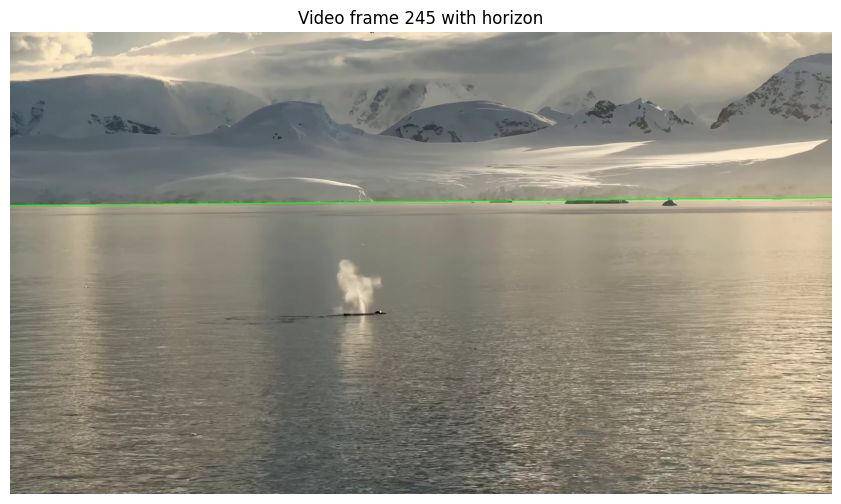

In [ ]:
n = 17  # pick the nth annotated frame to check
annotated_frames = sorted(horizons.keys())
print(len(annotated_frames))
frame_id = annotated_frames[n]  # directly the real video frame

print(f"Checking video frame {frame_id}")

cap = cv2.VideoCapture(video_filename)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError(f"❌ Could not read frame {frame_id} from video!")

# Draw horizon
for pts in horizons[frame_id]:
    pts_int = np.array(pts, np.int32)
    cv2.polylines(frame, [pts_int], isClosed=False, color=(0,255,0), thickness=2)

# Display
plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title(f"Video frame {frame_id} with horizon")
plt.axis("off")
plt.show()

In [ ]:
# Output folder in Google Drive
output_dir = "/content/drive/MyDrive/MIUN/QRD/implementation/images"
os.makedirs(output_dir, exist_ok=True)

# Function to check if two frames are similar
def is_similar(img1, img2, threshold=30):
    """Return True if two images are visually similar based on mean pixel difference."""
    if img1.shape != img2.shape:
        return False
    diff = cv2.absdiff(img1, img2)
    mean_diff = np.mean(diff)
    return mean_diff < threshold

annotated_frames = sorted(horizons.keys())
csv_rows = []

cap = cv2.VideoCapture(video_filename)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

prev_frame_small = None  # store previous frame (optionally resized for speed)

for i, frame_id in enumerate(tqdm(annotated_frames, desc="Extracting frames")):
    # Skip if frame number exceeds video length
    if frame_id >= total_frames:
        continue

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
    ret, frame = cap.read()
    if not ret:
        continue

    # Optionally resize for faster comparison
    frame_small = cv2.resize(frame, (320, 180))

    # Skip frame if very similar to previous saved frame
    if prev_frame_small is not None and is_similar(frame_small, prev_frame_small, threshold=7):
        continue

    # Save image
    out_filename = f"{name_data}_img_{frame_id:06d}.jpeg"

    print(out_filename)
    out_path = os.path.join(output_dir, out_filename)
    cv2.imwrite(out_path, frame)

    print()

    # Collect horizon coordinates
    for j, pts in enumerate(horizons[frame_id]):
        for k, (x, y) in enumerate(pts):
            csv_rows.append({
                "image_filename": out_filename,
                "frame_index": frame_id,
                "polyline_id": j,
                "point_index": k,
                "x": x,
                "y": y
            })

    # Update previous frame
    prev_frame_small = frame_small.copy()

cap.release()

# Save horizon coordinates CSV
csv_path = os.path.join(output_dir, f"horizon_coordinates_{name_data}.csv")
df = pd.DataFrame(csv_rows)
df.to_csv(csv_path, index=False)

print(f"✅ Saved {len(csv_rows)} horizon points and images to '{output_dir}/'.")

csv_path = os.path.join(output_dir, f"horizon_coordinates_{name_data}.csv")
df = pd.DataFrame(csv_rows)
df.to_csv(csv_path, index=False)
print(f"✅ Saved {len(df)} coordinate points to {csv_path}")


Extracting frames:   0%|          | 1/1476 [00:03<1:27:03,  3.54s/it]

boat_ice_1_img_000160.jpeg



Extracting frames:   0%|          | 2/1476 [00:05<1:11:18,  2.90s/it]

boat_ice_1_img_000165.jpeg



Extracting frames:   0%|          | 3/1476 [00:08<1:07:35,  2.75s/it]

boat_ice_1_img_000170.jpeg



Extracting frames:   0%|          | 4/1476 [00:15<1:35:41,  3.90s/it]


KeyboardInterrupt: 

Loaded 140 points from /content/drive/MyDrive/MIUN/QRD/implementation/images/horizon_coordinates_drone_ice_6.csv
Randomly selected frame: drone_ice_6_img_000000.jpeg


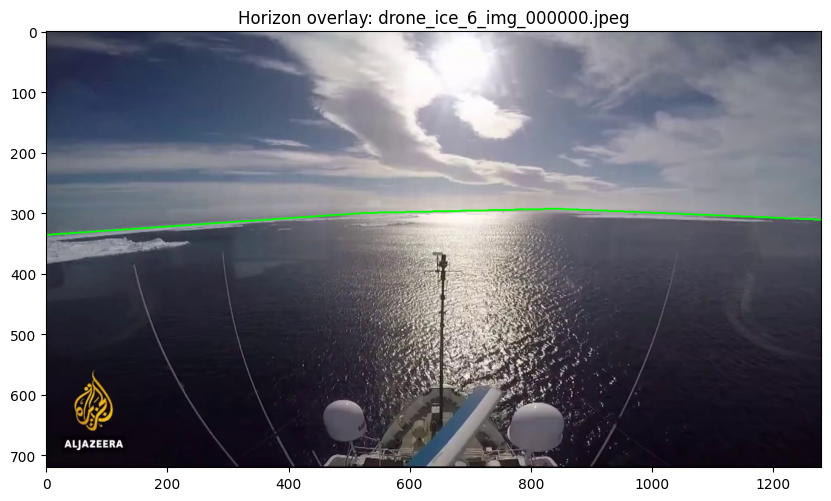

In [ ]:
import pandas as pd
import cv2
import os
import random
import matplotlib.pyplot as plt
import numpy as np

output_dir = "/content/drive/MyDrive/MIUN/QRD/implementation/images"
name_data = "drone_ice_6"
csv_path = os.path.join(output_dir, f"horizon_coordinates_{name_data}.csv")

# --- Load CSV ---
df = pd.read_csv(csv_path)
print(f"Loaded {len(df)} points from {csv_path}")

# --- Choose random frame ---
random_filename = random.choice(df["image_filename"].unique())
print(f"Randomly selected frame: {random_filename}")

# --- Get horizon points for this frame ---
frame_df = df[df["image_filename"] == random_filename]

# Group by polyline in case there are multiple per frame
polylines = []
for poly_id, group in frame_df.groupby("polyline_id"):
    pts = group[["x", "y"]].values.astype(np.int32)
    polylines.append(pts)

# --- Load image ---
img_path = os.path.join(output_dir, random_filename)
image = cv2.imread(img_path)
if image is None:
    raise FileNotFoundError(f"Image not found: {img_path}")

# Convert to RGB for matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# --- Draw horizon lines ---
for pts in polylines:
    cv2.polylines(image_rgb, [pts], isClosed=False, color=(0, 255, 0), thickness=2)

# --- Display result ---
plt.figure(figsize=(10, 6))
plt.imshow(image_rgb)
plt.title(f"Horizon overlay: {random_filename}")
# plt.axis("off")
plt.show()



# Unite all the csv with gt horizon to one file

In [ ]:
import os
import pandas as pd

def combine_gt_horizon_files(gt_folder, output_csv=None):
    """
    Combine all GT horizon coordinate files using column names from the first file.

    Parameters:
    -----------
    gt_folder : str
        Folder containing horizon coordinate CSVs (e.g. horizon_coordinates_*.csv)
    output_csv : str or None
        If provided, saves the combined DataFrame to this file.

    Returns:
    --------
    pd.DataFrame
        Combined DataFrame with unified columns and no duplicates.
    """
    all_files = sorted([
        os.path.join(gt_folder, f)
        for f in os.listdir(gt_folder)
        if f.startswith("horizon_coordinates_") and f.endswith(".csv")
    ])

    if not all_files:
        raise FileNotFoundError(f"No GT files found in {gt_folder}")

    # Read the first file and take its header
    first_file = all_files[0]
    first_df = pd.read_csv(first_file)
    col_names = first_df.columns.tolist()
    dfs = [first_df]

    print(f"Using columns from {os.path.basename(first_file)}: {col_names}")

    # Read remaining files with same columns
    for f in all_files[1:]:
        try:
            df = pd.read_csv(f, names=col_names, header=0)  # enforce same columns
            dfs.append(df)
            print(f"Loaded {os.path.basename(f)} ({len(df)} rows)")
        except Exception as e:
            print(f"Skipping {f} due to error: {e}")

    # Combine and deduplicate
    combined_df = pd.concat(dfs, ignore_index=True)
    combined_df = combined_df.drop_duplicates(subset=["image_filename", "point_index", "x", "y"], keep="first")

    if output_csv:
        combined_df.to_csv(output_csv, index=False)
        print(f"Combined GT file saved to {output_csv}")

    print(f"Total rows combined: {len(combined_df)} from {len(all_files)} files")
    return combined_df

In [ ]:
gt_folder = "/content/drive/MyDrive/MIUN/QRD/implementation/images"
output_csv = "/content/drive/MyDrive/MIUN/QRD/implementation/horizon_coordinates_all.csv"

gt_df = combine_gt_horizon_files(gt_folder, output_csv)

Using columns from horizon_coordinates_boat_ice_1.csv: ['image_filename', 'frame_index', 'polyline_id', 'point_index', 'x', 'y']
Loaded horizon_coordinates_boat_ice_2.csv (105 rows)
Loaded horizon_coordinates_boat_ice_3.csv (454 rows)
Loaded horizon_coordinates_drone_ice_4.csv (47 rows)
Loaded horizon_coordinates_drone_ice_5.csv (58 rows)
Loaded horizon_coordinates_drone_ice_6.csv (140 rows)
Loaded horizon_coordinates_drone_ice_cropped_4.csv (34 rows)
Combined GT file saved to /content/drive/MyDrive/MIUN/QRD/implementation/horizon_coordinates_all.csv
Total rows combined: 1695 from 7 files


# Take random image from the all coordinates csv file and draw the horizon

In [ ]:
import random

def draw_random_gt_horizon(gt_csv_path, images_folder):
    df_gt = pd.read_csv(gt_csv_path)
    df_gt['image_filename'] = df_gt['image_filename'].astype(str)

    random_image = random.choice(df_gt['image_filename'].unique())
    df_img = df_gt[df_gt['image_filename'] == random_image].sort_values('x')

    image_path = os.path.join(images_folder, random_image)
    if not os.path.exists(image_path):
        print(f" Image not found: {image_path}")
        return

    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gt_points = df_img[['x', 'y']].dropna().values.astype(int)
    if len(gt_points) >= 2:
        cv2.polylines(img_rgb, [gt_points.reshape(-1, 1, 2)], False, (255, 0, 0), 2)  # Blue = GT
    else:
        print(f" Not enough points for horizon in {random_image}")
        return


    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.title(f"Horizon for {random_image}")
    plt.axis("off")
    plt.show()

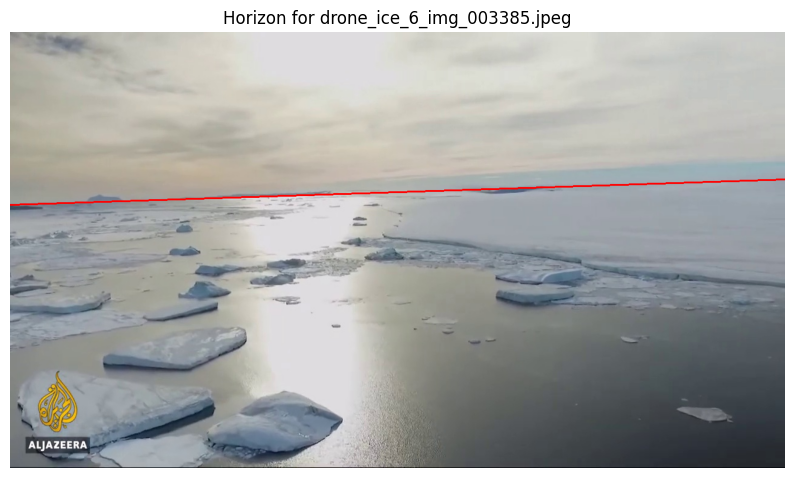

In [ ]:
gt_csv = "/content/drive/MyDrive/MIUN/QRD/implementation/horizon_coordinates_all.csv"
images_folder = "/content/drive/MyDrive/MIUN/QRD/implementation/images"

draw_random_gt_horizon(gt_csv, images_folder)